In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='svg'

**准备数据**

In [101]:
movies=pd.read_csv('movies.csv')
ratings=pd.read_csv('ratings2.csv')

In [102]:
movies.head(4)

,Unnamed: 0,movie_id,title,genres
0,0,1,Toy Story (1995),Animation|Children's|Comedy
1,1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,2,3,Grumpier Old Men (1995),Comedy|Romance
3,3,4,Waiting to Exhale (1995),Comedy|Drama


In [103]:
df=pd.merge(movies,ratings,left_on='movie_id',right_on='movie_id')
df.shape

(1000209, 7)

In [104]:
rating_counts=df.groupby('movie_id')['rating'].count()
popular_id=rating_counts[rating_counts>300]
popular_id

movie_id
1       2077
2        701
3        478
6        940
7        458
        ... 
3916     437
3927     348
3948     862
3949     304
3952     388
Name: rating, Length: 1053, dtype: int64

In [105]:
df = df[~df['movie_id'].isin(popular_id)]
df=df.drop(['timestamp'],axis=1)

In [106]:
df.shape

(838199, 6)

加载用户数据，合并到电影数据中

In [107]:
users=pd.read_csv('users.csv')
info=pd.read_csv('info.csv')
users

,Unnamed: 0,user_id,gender,age,occupation,zipcode,age_desc,occ_desc
0,0,1,F,1,10,48067,Under 18,K-12 student
1,1,2,M,56,16,70072,56+,self-employed
2,2,3,M,25,15,55117,25-34,scientist
3,3,4,M,45,7,02460,45-49,executive/managerial
4,4,5,M,25,20,55455,25-34,writer
...,...,...,...,...,...,...,...,...
6035,6035,6036,F,25,15,32603,25-34,scientist
6036,6036,6037,F,45,1,76006,45-49,academic/educator
6037,6037,6038,F,56,1,14706,56+,academic/educator
6038,6038,6039,F,45,0,01060,45-49,other or not specified


In [108]:
gend_only_users=users.drop(['age','occupation','zipcode','age_desc','occ_desc'],axis=1)
gend_only_users.head(3)

,Unnamed: 0,user_id,gender
0,0,1,F
1,1,2,M
2,2,3,M


In [109]:
male_users=gend_only_users.loc[gend_only_users['gender']=='M']['user_id'].values
female_users=gend_only_users.loc[gend_only_users['gender']=='F']['user_id'].values

In [110]:
full_df=pd.merge(df,gend_only_users,left_on='user_id',right_on='user_id',how='left')

In [111]:
task1_df=full_df.drop(['Unnamed: 0_x','Unnamed: 0_y'],axis=1)
task1_df.genres=task1_df.genres.apply(lambda x: x.split('|'))

In [112]:
len(list(popular_id.index))

1053

task1_df是这一部分进行性别偏好统计的出发点；

数据相比原本数据，去掉了评分少于300不够流行的电影，实际上流行电影的评分条数占到了绝大部分，所以去掉的数据无伤大雅。

In [113]:
task1_df=task1_df[task1_df['movie_id'].isin(list(popular_id.index))]
task1_df

,movie_id,title,genres,user_id,rating,gender
0,1,Toy Story (1995),"[Animation, Children's, Comedy]",1,5,F
1,1,Toy Story (1995),"[Animation, Children's, Comedy]",6,4,F
2,1,Toy Story (1995),"[Animation, Children's, Comedy]",8,4,M
3,1,Toy Story (1995),"[Animation, Children's, Comedy]",9,5,M
4,1,Toy Story (1995),"[Animation, Children's, Comedy]",10,5,F
...,...,...,...,...,...,...
838194,3952,"Contender, The (2000)","[Drama, Thriller]",5812,4,F
838195,3952,"Contender, The (2000)","[Drama, Thriller]",5831,3,M
838196,3952,"Contender, The (2000)","[Drama, Thriller]",5837,4,M
838197,3952,"Contender, The (2000)","[Drama, Thriller]",5927,1,M


In [114]:
rates=task1_df.groupby('gender').count()
rates

,movie_id,title,genres,user_id,rating
gender,,,,,
F,154373,154373,154373,154373,154373
M,486530,486530,486530,486530,486530


### 154373/486530为女性和男性留下评分的比。

In [115]:
female=154373
male=486530

In [116]:
df_ex = task1_df.explode('genres')
df_ex

#explode把电影类别拆开，便于统计；由于是按照genre分组的，不会造成混淆数据

,movie_id,title,genres,user_id,rating,gender
0,1,Toy Story (1995),Animation,1,5,F
0,1,Toy Story (1995),Children's,1,5,F
0,1,Toy Story (1995),Comedy,1,5,F
1,1,Toy Story (1995),Animation,6,4,F
1,1,Toy Story (1995),Children's,6,4,F
...,...,...,...,...,...,...
838196,3952,"Contender, The (2000)",Thriller,5837,4,M
838197,3952,"Contender, The (2000)",Drama,5927,1,M
838197,3952,"Contender, The (2000)",Thriller,5927,1,M
838198,3952,"Contender, The (2000)",Drama,5998,4,M


## 分别以电影类型和性别作为索引，统计每一类下总观看数和评分数据

In [117]:
likes_1=df_ex.groupby(['genres','gender']).agg({'movie_id': 'count', 'rating': 'mean'})
likes_1.head(6)

movie_id    rating
genres    gender                    
Action    F          34544  3.541483
          M         153890  3.554994
Adventure F          19088  3.574445
          M          75125  3.539887
Animation F           8710  3.800000
          M          22083  3.721279

In [118]:
likes_2=df_ex.groupby(['gender','genres']).agg({'movie_id': 'count', 'rating': 'mean'})
likes_2.head(5)

movie_id    rating
gender genres                        
F      Action         34544  3.541483
       Adventure      19088  3.574445
       Animation       8710  3.800000
       Children's     12450  3.748514
       Comedy         64543  3.686256

## 受两种性别观看数目前十的电影类别

In [119]:
female_best = likes_2.loc['F'].sort_values(by='movie_id', ascending=False).head(10).index
male_best=likes_2.loc['M'].sort_values(by='movie_id', ascending=False).head(10).index

In [120]:
colors_m = sns.color_palette('Blues_r',10)
colors_f= sns.color_palette('PuRd_r',10)

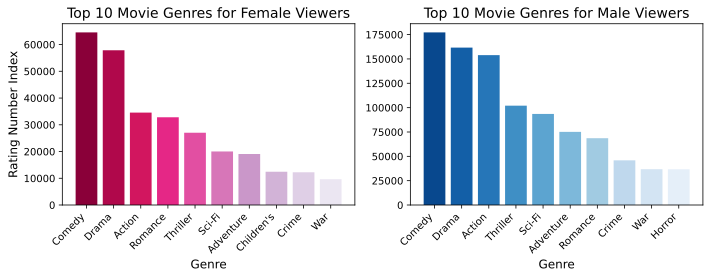

In [121]:
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(10,4))

for i, genre in enumerate(female_best):
    rating = likes_2.loc[('F', genre), 'movie_id']
    axs[0].bar(i, rating, color=colors_f[i])

axs[0].set_title("Top 10 Movie Genres for Female Viewers", fontsize=14)
axs[0].set_xlabel("Genre", fontsize=12)
axs[0].set_ylabel("Rating Number Index", fontsize=12)
axs[0].set_xticks(range(10), female_best, fontsize=10, rotation=45, ha='right')

for i, genre in enumerate(male_best):
    rating = likes_2.loc[('M', genre), 'movie_id']
    axs[1].bar(i, rating, color=colors_m[i])


axs[1].set_title("Top 10 Movie Genres for Male Viewers", fontsize=14)
axs[1].set_xlabel("Genre", fontsize=12)
axs[1].set_xticks(range(10), male_best, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top10.png')
plt.show()


## 双柱状图，统计性别偏好，做了正规化

In [122]:
# 将数据按照性别分为两个子数据集
male_data = likes_1.loc[likes_1.index.get_level_values('gender') == 'M']
female_data = likes_1.loc[likes_1.index.get_level_values('gender') == 'F']
tick_genres=[i[0] for i in male_data.index]

In [123]:
female_data['movie_id']=female_data['movie_id']*(male/female)
#正规化

C:\Users\wangr\AppData\Local\Temp\ipykernel_14164\3231832529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female_data['movie_id']=female_data['movie_id']*(male/female)


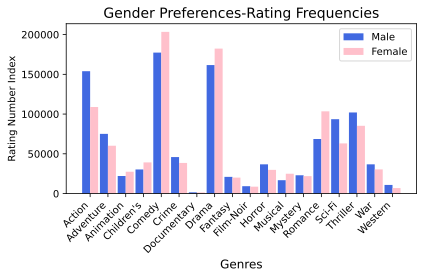

In [124]:
fig, ax = plt.subplots(figsize=(6, 4))
barwidth=0.45
index = np.arange(len(tick_genres))
# 绘制男性和女性的柱状图
ax.bar(index-barwidth/2, male_data['movie_id'], width=barwidth,label='Male',color='royalblue')
ax.bar(index+barwidth/2,female_data['movie_id'], width=barwidth,label='Female',color='pink')

ax.legend()
ax.set_xlabel('Genres',fontsize=12)
ax.set_ylabel('Rating Number Index')
ax.set_title('Gender Preferences-Rating Frequencies',fontsize=14)
ax.set_xticks(range(len(tick_genres)),tick_genres, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('freq.png')
plt.show()

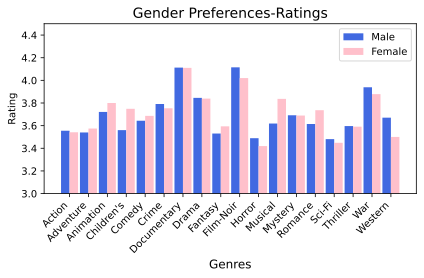

In [125]:
fig, ax = plt.subplots(figsize=(6, 4))
barwidth=0.45
index = np.arange(len(tick_genres))
# 绘制男性和女性的柱状图
ax.bar(index-barwidth/2, male_data['rating'], width=barwidth,label='Male',color='royalblue')
ax.bar(index+barwidth/2,female_data['rating'], width=barwidth,label='Female',color='pink')

ax.legend()
ax.set_xlabel('Genres',fontsize=12)
ax.set_ylabel('Rating')
ax.set_ylim([3.0,4.5])
ax.set_title('Gender Preferences-Ratings',fontsize=14)
ax.set_xticks(range(len(tick_genres)),tick_genres, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rate.png')
plt.show()

In [126]:
low_scored=df_ex.groupby(['genres','gender']).agg({'gender':'count','rating':lambda x:sum((x<=2))/len(x)})
low_scored.columns=['numbers','low_score rate']
low_scored.head(6)

numbers  low_score rate
genres    gender                         
Action    F         34544        0.173373
          M        153890        0.169537
Adventure F         19088        0.167854
          M         75125        0.174296
Animation F          8710        0.100459
          M         22083        0.114975

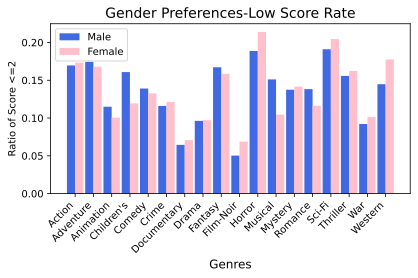

In [127]:
male_data = low_scored.loc[low_scored.index.get_level_values('gender') == 'M']
female_data = low_scored.loc[low_scored.index.get_level_values('gender') == 'F']
tick_genres=[i[0] for i in male_data.index]

fig, ax = plt.subplots(figsize=(6, 4))
barwidth=0.45
index = np.arange(len(tick_genres))
# 绘制男性和女性的柱状图
ax.bar(index-barwidth/2, male_data['low_score rate'], width=barwidth,label='Male',color='royalblue')
ax.bar(index+barwidth/2,female_data['low_score rate'], width=barwidth,label='Female',color='pink')

ax.legend()
ax.set_xlabel('Genres',fontsize=12)
ax.set_ylabel('Ratio of Score <=2')
ax.set_title('Gender Preferences-Low Score Rate',fontsize=14)
ax.set_xticks(range(len(tick_genres)),tick_genres, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('lows.png')
plt.show()

### 下面统计观看过不同性别观看过某一电影类别的比例

In [128]:
def func(x):   
    return len(set(x['user_id']))
watched_number=pd.DataFrame(df_ex.groupby(['genres','gender']).apply(lambda x: func(x)),columns=['watched_number'])
watched_number.head(6)

watched_number
genres    gender                
Action    F                 1684
          M                 4306
Adventure F                 1586
          M                 4179
Animation F                 1278
          M                 3332

In [129]:
def func(x):
    return (x.iloc[0,0]/len(female_users),x.iloc[1,0]/len(male_users))  
watched_portion=pd.DataFrame(watched_number.groupby(level=0).apply(func),columns=['watched_portion'])

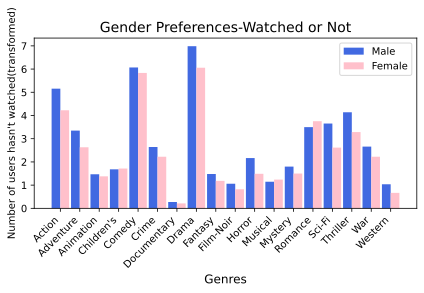

In [130]:
male_data=[1-i[1] for i in watched_portion.watched_portion.values]
female_data=[1-i[0] for i in watched_portion.watched_portion.values]
fig, ax = plt.subplots(figsize=(6, 4))
barwidth=0.45
index = np.arange(len(tick_genres))
# 绘制男性和女性的柱状图
ax.bar(index-barwidth/2, -np.log(male_data), width=barwidth,label='Male',color='royalblue')
ax.bar(index+barwidth/2,-np.log(female_data), width=barwidth,label='Female',color='pink')
#这里做了对数变换，对0-1之间的数目放大其差距

ax.legend()
ax.set_xlabel('Genres',fontsize=12)
ax.set_ylabel('Number of users hasn\'t watched(transformed)')
ax.set_title('Gender Preferences-Watched or Not',fontsize=14)
ax.set_xticks(range(len(tick_genres)),tick_genres, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ifnot.png')
plt.show()

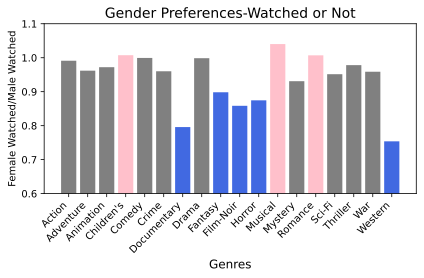

In [131]:
watched_ratio=[i[0]/i[1] for i in watched_portion.watched_portion.values]
fig, ax = plt.subplots(figsize=(6, 4))
barwidth=0.9
index = np.arange(len(tick_genres))
# 绘制男性和女性的柱状图
for i, x in enumerate(watched_ratio):
    if x < 0.9:
        plt.bar(i, x, color='royalblue')
    elif x>1:
        plt.bar(i, x, color='pink')
    else:
        plt.bar(i, x, color='gray')
ax.set_xlabel('Genres',fontsize=12)
ax.set_ylabel('Female Watched/Male Watched')
ax.set_title('Gender Preferences-Watched or Not',fontsize=14)
ax.set_ylim([0.6,1.1])
ax.set_xticks(range(len(tick_genres)),tick_genres, fontsize=10, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ifnot_colored.png')
plt.show()

上面的图中，蓝色柱子说明男性看过的比女性看过的比例高很多，粉色柱子说明女性看过的比男性看过的多。

为什么蓝色可以出现较低比例而超过1的比例很少？个人观点是因为女性的评分数量本就是男性的四分之一左右，和男性相比，女性不喜欢上这个网站评分。

### 下面筛选男性和女性代表电影：

我提出了两套方案，由于数据集中的电影还是很多的，我无法从某个量化标准直接判断出两个方案的优劣。
所以我使用了类似“人工标注”的方式，发问卷让同学们进行了投票和评价。评价的结果是很难确定谁更好，具体的阐述在报告中。

In [132]:
df_to_comp=task1_df.groupby(['movie_id','gender']).agg({'movie_id':'count','rating':'mean'})
df_to_comp.columns=['watched','ratings']
df_to_comp.head(4)

watched   ratings
movie_id gender                   
1        F           591  4.187817
         M          1486  4.130552
2        F           176  3.278409
         M           525  3.175238

In [133]:
#平均每个电影被观看过的次数
ave_watched=np.average(task1_df.groupby('movie_id')['movie_id'].count().values)
rating_watched=np.average(task1_df.groupby('movie_id')['rating'].mean().values)
print(ave_watched,rating_watched)
ratio=rating_watched/ave_watched
ratio

709.7486157253599 3.5678632283926803


0.0050269393266041676

这是方案之一：

有两个变量，男女观看数之差和男女平均打分之差，这两者的权重难以确定。所以设置动态的权重即ind_score。对八个不同权重方案分别计算并排名，得到的序列进行取交集，对所有权重都排在前面的电影才能入选。

In [134]:
w1=male/(male+female)
w2=1-w1

ind_score=np.arange(0.1,0.9,0.1)
ind_score

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

In [135]:
def score_1(x):
    return x.iloc[0,0]/w2*x.iloc[1,1]-x.iloc[1,0]/w1*x.iloc[0,1]

In [136]:
def score_2(x,i):
    return ratio*(x.iloc[0,0]-x.iloc[1,0])*ind_score[i]+(x.iloc[0,1]-x.iloc[1,1])*(1-ind_score[i])
##########ratio是男女比，正规化

方案之二：

这一评价方案是对每个电影男女观看数和评分形成的2x2矩阵**取行列式**。如果男性看得少，评分低，女性看的多，评分高，这个行列式就会很大，反之会很小。同时，这一操作方式也免去了正则化的麻烦，因为只要不进行非线性变换，行列式值的序关系都不变。

带alt是方案二的，但是由于思路的关系在前面出现wwwwww

In [137]:
alt_res=df_to_comp.groupby(level=0).apply(lambda x:score_1(x)).sort_values(ascending=False)
alt_rec_male = pd.DataFrame()

In [138]:
for movie in alt_res[882:902].index:##############分数低的推荐给男性
    alt_rec_male = pd.concat([alt_rec_male, movies.loc[movies['movie_id'] == movie]], ignore_index=True)
alt_rec_male

,Unnamed: 0,movie_id,title,genres
0,2571,2640,Superman (1978),Action|Adventure|Sci-Fi
1,1539,1580,Men in Black (1997),Action|Adventure|Comedy|Sci-Fi
2,1349,1370,Die Hard 2 (1990),Action|Thriller
3,1696,1748,Dark City (1998),Film-Noir|Sci-Fi|Thriller
4,1630,1676,Starship Troopers (1997),Action|Adventure|Sci-Fi|War
5,1197,1215,Army of Darkness (1993),Action|Adventure|Comedy|Horror|Sci-Fi
6,5,6,Heat (1995),Action|Crime|Thriller
7,1355,1376,Star Trek IV: The Voyage Home (1986),Action|Adventure|Sci-Fi
8,1351,1372,Star Trek VI: The Undiscovered Country (1991),Action|Adventure|Sci-Fi
9,1230,1250,"Bridge on the River Kwai, The (1957)",Drama|War


In [139]:
alt_rec_female = pd.DataFrame()
for movie in alt_res[0:19].index:##############分数高的推荐给女性
    alt_rec_female = pd.concat([alt_rec_female, movies.loc[movies['movie_id'] == movie]], ignore_index=True)
alt_rec_female

,Unnamed: 0,movie_id,title,genres
0,2327,2396,Shakespeare in Love (1998),Comedy|Romance
1,16,17,Sense and Sensibility (1995),Drama|Romance
2,2789,2858,American Beauty (1999),Comedy|Drama
3,33,34,Babe (1995),Children's|Comedy|Drama
4,262,265,Like Water for Chocolate (Como agua para choco...,Drama|Romance
5,1245,1265,Groundhog Day (1993),Comedy|Romance
6,908,920,Gone with the Wind (1939),Drama|Romance|War
7,1171,1188,Strictly Ballroom (1992),Comedy|Romance
8,1529,1569,My Best Friend's Wedding (1997),Comedy|Romance
9,593,597,Pretty Woman (1990),Comedy|Romance


In [140]:
result=[]
for i in range(8):
    res=df_to_comp.groupby(level=0).apply(lambda x:score_2(x,i)).sort_values(ascending=False)
    result.append(res)

In [141]:
fav_female=[]
for i in result[0].index:
    flag=1
    for res in result:
        if res.index.get_loc(i)>=40:##############分数高的推荐给女性
            flag=0
    if flag==1 and i not in fav_female:
        fav_female.append(i)
fav_female.pop()
len(fav_female)

20

In [142]:
fav_male=[]
for i in result[0].index:
    flag=1
    for res in result:
        if res.index.get_loc(i)<=870:
            flag=0
    if flag==1 and i not in fav_male:
        fav_male.append(i)
len(fav_male)

20

In [143]:
rec_male = pd.DataFrame()
for movie in fav_male:
    rec_male = pd.concat([rec_male, movies.loc[movies['movie_id'] == movie]], ignore_index=True)
rec_male

,Unnamed: 0,movie_id,title,genres
0,1250,1270,Back to the Future (1985),Comedy|Sci-Fi
1,1023,1036,Die Hard (1988),Action|Thriller
2,2559,2628,Star Wars: Episode I - The Phantom Menace (1999),Action|Adventure|Fantasy|Sci-Fi
3,1245,1265,Groundhog Day (1993),Comedy|Romance
4,912,924,2001: A Space Odyssey (1968),Drama|Mystery|Sci-Fi|Thriller
5,293,296,Pulp Fiction (1994),Crime|Drama
6,2847,2916,Total Recall (1990),Action|Adventure|Sci-Fi|Thriller
7,3458,3527,Predator (1987),Action|Sci-Fi|Thriller
8,1180,1198,Raiders of the Lost Ark (1981),Action|Adventure
9,1203,1221,"Godfather: Part II, The (1974)",Action|Crime|Drama


In [144]:
rec_female = pd.DataFrame()
for movie in fav_female:
    rec_female = pd.concat([rec_female, movies.loc[movies['movie_id'] == movie]], ignore_index=True)
rec_female

,Unnamed: 0,movie_id,title,genres
0,1072,1088,Dirty Dancing (1987),Musical|Romance
1,3774,3844,Steel Magnolias (1989),Drama
2,1642,1688,Anastasia (1997),Animation|Children's|Musical
3,233,236,French Kiss (1995),Comedy|Romance
4,2670,2739,"Color Purple, The (1985)",Drama
5,1819,1888,Hope Floats (1998),Comedy|Drama|Romance
6,16,17,Sense and Sensibility (1995),Drama|Romance
7,1360,1381,Grease 2 (1982),Comedy|Musical|Romance
8,2056,2125,Ever After: A Cinderella Story (1998),Drama|Romance
9,903,915,Sabrina (1954),Comedy|Romance
